In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
train_df = pd.read_csv("../data/train_processed.csv")
test_df = pd.read_csv("../data/test_processed.csv")

In [4]:
X_train = train_df.drop(columns=["ClosePrice"])
y_train = train_df["ClosePrice"]

X_test = test_df.drop(columns=["ClosePrice"])
y_test = test_df["ClosePrice"]

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [6]:
def evaluate(model):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    mape = (
        np.abs(
            (y_test - predictions)
            / y_test
        ).mean()
        * 100
    )

    return mae, rmse, mape, r2

In [7]:
results = []

for name, model in models.items():

    mae, rmse, mape, r2 = evaluate(model)

    results.append([
        name,
        mae,
        rmse,
        mape,
        r2
    ])

In [8]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ]
)

comparison

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,185741.808070,1.158377e+06,22.233643,0.523476
1,Decision Tree,97711.987120,1.011477e+06,8.973806,0.636674
2,Random Forest,104269.150755,1.711897e+06,10.923685,-0.040735
3,Gradient Boosting,223104.643212,4.144732e+06,30.386952,-5.100674


In [9]:
comparison = comparison.sort_values(
    "R2",
    ascending=False
)

comparison

,Model,MAE,RMSE,MAPE,R2
1,Decision Tree,97711.987120,1.011477e+06,8.973806,0.636674
0,Linear Regression,185741.808070,1.158377e+06,22.233643,0.523476
2,Random Forest,104269.150755,1.711897e+06,10.923685,-0.040735
3,Gradient Boosting,223104.643212,4.144732e+06,30.386952,-5.100674


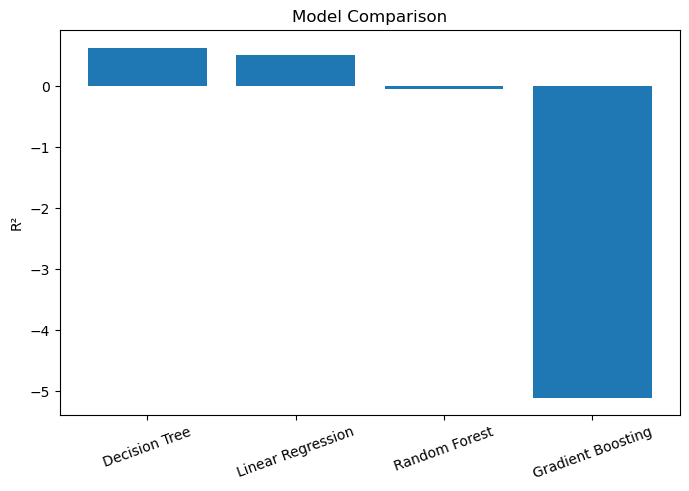

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.ylabel("R²")

plt.title("Model Comparison")

plt.xticks(rotation=20)

plt.show()

In [11]:
comparison.to_csv(
    "../reports/comparison_metrics.csv",
    index=False
)

In [12]:
for name, model in models.items():

    model.fit(X_train, y_train)

    filename = (
        "../models/"
        + name.lower().replace(" ", "_")
        + ".pkl"
    )

    joblib.dump(
        model,
        filename
    )

# Week 5 Summary

Compared four regression algorithms for California property price prediction.

Models evaluated:

- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Metrics used:

- MAE
- RMSE
- MAPE
- R²

The best-performing model will be used as the starting point for feature engineering and hyperparameter tuning in Week 6.